In [1]:
import sqlite3
import pandas as pd
import numpy as np
import pickle
import re
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

print("Libraries imported successfully")

Libraries imported successfully


In [21]:
df_all = pd.read_pickle("../data/tags_alteration_full_2025-10_dm.pkl")

In [22]:
df = df_all[df_all['status'] != 'non-legit'].copy()

print(f"Total alterations: {len(df_all):_}")
print(f"Alterations used (excluding non-legit): {len(df):_}")
print(f"Non-legit filtered out: {len(df_all) - len(df):_}")

Total alterations: 15_166_153
Alterations used (excluding non-legit): 10_815_603
Non-legit filtered out: 4_350_550


In [23]:
print(f"{len(df):_}")

10_815_603


In [24]:
df[df['status']=="legit"]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
733,https://github.com/membphis/apisix,refs/tags/v0.8,annotated,swh:1:snp:23350c33758fcbee37ee8a67f2cf91bf1a199460,0,2020-06-04 08:13:01,swh:1:rev:9bb2174e0434ea46646bc632b122799f49dcf097,2019-09-29 01:00:23,swh:1:dir:f93a4d8afbe8b32200e53355526a9ffbf06a93e2,swh:1:snp:d27a552c700fb1f901ac5c88e7d140720e8c849d,2,2022-04-11 01:20:54,NaN,NaT,NaN,2021-06-20 02:06:24,2022,NaN,Deletion,380,GitHub,0.0,lightweight,swh:1:rev:b65bb153fa9014f56518c44ef9444084502976a6,2019-09-29 07:55:10,swh:1:dir:ce2c8e405ab26c5c2295dd57cdbcaa08d164ae54,d27a552c700fb1f901ac5c88e7d140720e8c849d,2022-04-11 01:20:54,2022-04-11 01:20:54,0 days,legit
842,https://github.com/projectstorm/serve,refs/tags/v1.4.1,lightweight,swh:1:snp:cb6ae5ef63cfd524fae6ce29cf1028781da77922,0,2015-09-25 05:58:29,swh:1:rev:6312fb693a1c90ce2d642c9cb9c2dde6adeb8f23,2015-07-14 08:59:16,swh:1:dir:c0da319ef4f0d76088e1c13940fb2a0eca930caf,swh:1:snp:c7787e60074b94b548d6481f2637de00b87d8f37,1,2016-03-12 17:36:16,NaN,NaT,NaN,2015-09-25 05:58:29,2016,NaN,Deletion,0,GitHub,NaN,annotated,swh:1:rev:6312fb693a1c90ce2d642c9cb9c2dde6adeb8f23,2015-07-14 08:59:16,swh:1:dir:c0da319ef4f0d76088e1c13940fb2a0eca930caf,c7787e60074b94b548d6481f2637de00b87d8f37,2016-03-12 17:36:16,2016-03-12 17:36:16,0 days,legit
843,https://github.com/projectstorm/serve,refs/tags/v1.1.0,lightweight,swh:1:snp:cb6ae5ef63cfd524fae6ce29cf1028781da77922,0,2015-09-25 05:58:29,swh:1:rev:3d3cab6b491ec99ba6772938213183341e16ee5e,2015-05-28 17:47:53,swh:1:dir:9fc6ee00b07998fa73b999126d90964df667fd05,swh:1:snp:c7787e60074b94b548d6481f2637de00b87d8f37,1,2016-03-12 17:36:16,NaN,NaT,NaN,2015-09-25 05:58:29,2016,NaN,Deletion,0,GitHub,NaN,annotated,swh:1:rev:3d3cab6b491ec99ba6772938213183341e16ee5e,2015-05-28 17:47:53,swh:1:dir:9fc6ee00b07998fa73b999126d90964df667fd05,c7787e60074b94b548d6481f2637de00b87d8f37,2016-03-12 17:36:16,2016-03-12 17:36:16,0 days,legit
844,https://github.com/projectstorm/serve,refs/tags/v1.4.2,lightweight,swh:1:snp:cb6ae5ef63cfd524fae6ce29cf1028781da77922,0,2015-09-25 05:58:29,swh:1:rev:4b42db226c9dd48a7332edb85b2b148968c2fd48,2015-07-25 14:42:53,swh:1:dir:e3e6580addd39667a1af073b901004adad69e6c4,swh:1:snp:c7787e60074b94b548d6481f2637de00b87d8f37,1,2016-03-12 17:36:16,NaN,NaT,NaN,2015-09-25 05:58:29,2016,NaN,Deletion,0,GitHub,NaN,annotated,swh:1:rev:4b42db226c9dd48a7332edb85b2b148968c2fd48,2015-07-25 14:42:53,swh:1:dir:e3e6580addd39667a1af073b901004adad69e6c4,c7787e60074b94b548d6481f2637de00b87d8f37,2016-03-12 17:36:16,2016-03-12 17:36:16,0 days,legit
1108,https://github.com/InTheNow/scala-bricks,refs/tags/v0.0.0,lightweight,swh:1:snp:1eadff41c8af217eff0142aa49c0c2f4eaa84946,0,2015-09-26 03:00:14,swh:1:rev:6ef9e7640cd380c081ced28697b5aff85bd11a5c,2015-09-05 16:33:29,swh:1:dir:8d3c5de70419db14a30974ee26e23401bf3b09bf,swh:1:snp:779c948f19d8ff748d946ac98e64c6604595e6ec,1,2016-03-04 03:29:55,NaN,NaT,NaN,2015-09-26 03:00:14,2016,NaN,Deletion,0,GitHub,NaN,annotated,swh:1:rev:6ef9e7640cd380c081ced28697b5aff85bd11a5c,2015-09-05 16:33:29,swh:1:dir:8d3c5de70419db14a30974ee26e23401bf3b09bf,779c948f19d8ff748d946ac98e64c6604595e6ec,2016-03-04 03:29:55,2016-03-04 03:29:55,0 days,legit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15165675,https://github.com/wavefrontHQ/ruby-client,refs/tags/v1.0.2,lightweight,swh:1:snp:0a55114163489b669aadcb0878430ceb69a42a98,0,2015-09-24 22:42:14,swh:1:rev:04741e540cc430ecb149e9f3877b897e8595bd37,2015-08-28 21:58:43,swh:1:dir:93451ff3d24dc5080f38022b522269a7121b3de2,swh:1:snp:529429b58be5476d9d54be5b096a992b9476a76a,1,2016

In [25]:
analyzed_origins = 328_424_115 # more than 1 snapshot
skipped_origins = 74_425_148 # 1 snapshot or less
relevant_origins = 45_525_442 # at least 1 tag and 2 snapshots
total_tags = 3_197_620_436
total_l_tags = 1_417_510_761
total_a_tags = 1_780_109_675
unknown_branch = 819

## SSC Attack

Forks of `tj-actions/changed-files`

In [26]:
df[(df['origin_url'].str.contains("changed-files")) & (df['new_revision'].str.contains('0e58ed8'))]

,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
2198205,https://github.com/zendesk/changed-files,refs/tags/v18.7,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:a59f800cbb60ed483623848e31be67659a2940f8,2022-04-08 09:43:01,swh:1:dir:06e64979ae45fcd6a2a9b8b91b4a81cbcabe8e65,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198207,https://github.com/zendesk/changed-files,refs/tags/v37.2.0,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:68b429ddc666ea0dba46309e1ee45e06bb408df8,2023-07-18 17:41:01,swh:1:dir:ccab5fe2e97c81819606b28711e170e37904cc43,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198209,https://github.com/zendesk/changed-files,refs/tags/v18.4,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:e35d0afdc1f0b01f84ec0f4cdf1b179325634b36,2022-03-21 01:30:28,swh:1:dir:f4e749fa02bfc8a8a9ee4d5816586302a6d01619,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198211,https://github.com/zendesk/changed-files,refs/tags/v37.5.1,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:a96679dfee2a1e64b1db5a210c0ffaf1f2cb24ce,2023-07-28 19:34:23,swh:1:dir:63692aa7571c374eac46d4f60f044e7c67659fba,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198213,https://github.com/zendesk/changed-files,refs/tags/v34.0.0,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:c4d29bf5b2769a725bcc9a723c498ba9c34c05b4,2022-10-25 22:04:27,swh:1:dir:3940140177acbd1edeb44d119c2508ebae1f712f,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2198893,https://github.com/zendesk/changed-files,refs/tags/v43.0.1,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024-09-20 23:18:29,swh:1:rev:20576b4b9ed46d41e2d45a2256e5e2316dde6834,2024-03-20 21:58:07,swh:1:dir:785398deebfb6e69eebd65156e7472f980c955de,swh:1:snp:b2acad3bf9a7533de8360c346de440df7d859b92,9,2025-03-15 14:12:10,swh:1:rev:0e58ed8671d6b60d0890c21b07f8835ace038e67,2025-03-14 16:57:45,swh:1:dir:e7184c732b62349a7b7177a07fd80e82601f370a,2025-02-15 23:27:01,2025,2025.0,Move,148,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2198895,https://github.com/zendesk/changed-files,refs/tags/v35.6.3,lightweight,swh:1:snp:e49d3cef71c6999c581e52270685f5964c14f5bc,0,2024

# Proportions

In [27]:
print(f"Amount of Alterations: {len(df):_}")
print(f"Meaning {(len(df)/total_tags)*100:.2f}% of total tags")

Amount of Alterations: 10_815_603
Meaning 0.34% of total tags


In [28]:
moves = df[df['category']=="Alteration"]
deletions = df[df['category']=="Deletion"]

In [29]:
annotated = df[df['type']=="annotated"]
lightweight = df[df['type']=="lightweight"]
unique_origins = df['origin_url'].drop_duplicates().reset_index(drop=True)

In [30]:
print(f"Origin with an altered tag: {(len(unique_origins)/relevant_origins)*100:.2f}%")
print(f"Proportion of altered annotated tags: {(len(annotated)/total_a_tags)*100:.2f}%")
print(f"Proportion of altered lightweight tags: {(len(lightweight)/total_l_tags)*100:.2f}%")

Origin with an altered tag: 0.50%
Proportion of altered annotated tags: 0.25%
Proportion of altered lightweight tags: 0.45%


In [31]:
# Parse tags_count.log file
import re

tags_monthly_data = []

with open('../data/tags_count.log', 'r') as f:
    # Skip lines until we find the header
    for line in f:
        if line.strip().startswith('Month'):
            # Skip the separator line
            next(f)
            break
    
    # Parse data lines
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        # Parse lines with format: "1970-01    1621    307883    0    309504"
        parts = line.split()
        if len(parts) >= 5:
            try:
                month = parts[0]
                lightweight = int(parts[1])
                annotated = int(parts[2])
                unknown = int(parts[3])
                total = int(parts[4])
                
                tags_monthly_data.append({
                    'month': month,
                    'lightweight': lightweight,
                    'annotated': annotated,
                    'unknown': unknown,
                    'total': total
                })
            except ValueError:
                # Skip lines that don't match expected format
                continue

# Create DataFrame
tags_monthly_df = pd.DataFrame(tags_monthly_data)

print(f"Loaded {len(tags_monthly_df):_} months of data")
print(f"\nDate range: {tags_monthly_df['month'].iloc[0]} to {tags_monthly_df['month'].iloc[-1]}")
print(f"\nFirst few rows:")
print(tags_monthly_df.head())
print(f"\nLast few rows:")
print(tags_monthly_df.tail())

Loaded 579 months of data

Date range: 1970-01 to 2188-05

First few rows:
     month  lightweight  annotated  unknown   total
0  1970-01         1621     307883        0  309504
1  1970-03            0          1        0       1
2  1970-06            0        383        0     383
3  1971-02            1          0        0       1
4  1971-11            0          1        0       1

Last few rows:
       month  lightweight  annotated  unknown  total
574  2099-01           29          0        0     29
575  2099-03            0          7        0      7
576  2099-12           15          2        0     17
577  2106-02            0         36        0     36
578  2188-05            0          1        0      1


In [32]:
# Check temporal columns in alterations dataframe
print("Alterations DataFrame columns:")
print(df.columns.tolist())
print(f"\nSample rows:")
df.head(3)

Alterations DataFrame columns:
['origin_url', 'tag_name', 'type', 'old_snapshot', 'old_snapshot_cpt', 'old_snap_timestamp', 'old_revision', 'old_rev_timestamp', 'old_root_dir', 'new_snapshot', 'new_snapshot_cpt', 'new_snap_timestamp', 'new_revision', 'new_rev_timestamp', 'new_root_dir', 'min_delta', 'snap_year', 'rev_year', 'category', 'delta', 'platform', 'stars', 'creation_type', 'creation_rev', 'creation_rev_ts', 'creation_root_dir', 'creation_snapshot', 'creation_snap_ts', 'creation_delta', 'deadtime', 'status']

Sample rows:


,origin_url,tag_name,type,old_snapshot,old_snapshot_cpt,old_snap_timestamp,old_revision,old_rev_timestamp,old_root_dir,new_snapshot,new_snapshot_cpt,new_snap_timestamp,new_revision,new_rev_timestamp,new_root_dir,min_delta,snap_year,rev_year,category,delta,platform,stars,creation_type,creation_rev,creation_rev_ts,creation_root_dir,creation_snapshot,creation_snap_ts,creation_delta,deadtime,status
1,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:29e7fce9fc88a55bdafb507f6506bd6f153260b0,2020-04-27 03:35:14,swh:1:dir:c612010c922cea11ecdfa384db474123a0225d73,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,2,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
2,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/2.2.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:16a7fefff1f1fb674d1ed0328099a8d6ac0d38bb,2020-04-27 19:31:38,swh:1:dir:3727b13bc24dad71024adebc98eb17a2b9310d35,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,2,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN
3,https://github.com/innovation-cat/innovation-cat.github.io,refs/tags/3.0.0,lightweight,swh:1:snp:d10c567a401e6a134a99899681bb2ee90007be0d,1,2022-03-05 08:11:53,swh:1:rev:85401c9f014ff7d8950b1930e732b73fd6d08043,2020-05-07 07:24:36,swh:1:dir:65029e9180c14f7e3c5d0d1d3cf0b9b697b5e60e,swh:1:snp:bd6d353312a43153ac7a927924bcf04e3c77e771,2,2022-03-12 17:36:22,NaN,NaT,NaN,2022-03-05 08:11:53,2022,NaN,Deletion,0,GitHub,0.0,NaN,NaN,NaT,NaN,NaN,NaT,NaT,NaT,NaN


## Temporal Evolution of Tag Alterations

In [33]:
# Convert timestamps to datetime and extract year-month
df['alteration_date'] = pd.to_datetime(df['new_snap_timestamp'], unit='s', errors='coerce')
df['alteration_month'] = df['alteration_date'].dt.strftime('%Y-%m')

# Group alterations by month
alterations_by_month = df.groupby('alteration_month').agg({
    'tag_name': 'count',  # Total alterations
    'type': lambda x: (x == 'annotated').sum()  # Annotated alterations
}).rename(columns={'tag_name': 'total_alterations', 'type': 'annotated_alterations'})

# Calculate lightweight alterations
alterations_by_month['lightweight_alterations'] = (
    alterations_by_month['total_alterations'] - alterations_by_month['annotated_alterations']
)

# Reset index to make month a column
alterations_by_month = alterations_by_month.reset_index()

# Calculate CUMULATIVE tags (tags existing up to that month)
tags_monthly_df['cumulative_total'] = tags_monthly_df['total'].cumsum()
tags_monthly_df['cumulative_lightweight'] = tags_monthly_df['lightweight'].cumsum()
tags_monthly_df['cumulative_annotated'] = tags_monthly_df['annotated'].cumsum()

# Merge with monthly tags data
temporal_analysis = tags_monthly_df.merge(
    alterations_by_month, 
    left_on='month', 
    right_on='alteration_month', 
    how='left'
)

# Fill NaN values with 0 for months with no alterations
temporal_analysis['total_alterations'] = temporal_analysis['total_alterations'].fillna(0).astype(int)
temporal_analysis['annotated_alterations'] = temporal_analysis['annotated_alterations'].fillna(0).astype(int)
temporal_analysis['lightweight_alterations'] = temporal_analysis['lightweight_alterations'].fillna(0).astype(int)

# Calculate normalized metrics using CUMULATIVE tags (alterations per 1000 existing tags)
temporal_analysis['alterations_per_1000'] = (
    temporal_analysis['total_alterations'] / temporal_analysis['cumulative_total'] * 1000
)
temporal_analysis['annotated_alt_per_1000'] = (
    temporal_analysis['annotated_alterations'] / temporal_analysis['cumulative_annotated'] * 1000
).replace([np.inf, -np.inf], 0)
temporal_analysis['lightweight_alt_per_1000'] = (
    temporal_analysis['lightweight_alterations'] / temporal_analysis['cumulative_lightweight'] * 1000
).replace([np.inf, -np.inf], 0)

# Drop the duplicate month column
temporal_analysis = temporal_analysis.drop(columns=['alteration_month'], errors='ignore')

print("=" * 70)
print("TEMPORAL ANALYSIS (EXCLUDING NON-LEGIT)")
print("=" * 70)
print(f"Total months analyzed: {len(temporal_analysis):_}")
print(f"Months with alterations: {(temporal_analysis['total_alterations'] > 0).sum():_}")
print(f"\nSummary statistics (normalized per 1000 EXISTING tags):")
print(f"  Mean alterations per 1000 tags: {temporal_analysis['alterations_per_1000'].mean():.4f}")
print(f"  Median alterations per 1000 tags: {temporal_analysis['alterations_per_1000'].median():.4f}")
print(f"  Max alterations per 1000 tags: {temporal_analysis['alterations_per_1000'].max():.4f}")
print(f"\nFinal cumulative totals:")
print(f"  Total tags existing: {temporal_analysis['cumulative_total'].iloc[-1]:_}")
print(f"  Lightweight: {temporal_analysis['cumulative_lightweight'].iloc[-1]:_}")
print(f"  Annotated: {temporal_analysis['cumulative_annotated'].iloc[-1]:_}")
print("\n" + "=" * 70)

temporal_analysis.head(10)

TEMPORAL ANALYSIS (EXCLUDING NON-LEGIT)
Total months analyzed: 579
Months with alterations: 117

Summary statistics (normalized per 1000 EXISTING tags):
  Mean alterations per 1000 tags: 0.0070
  Median alterations per 1000 tags: 0.0000
  Max alterations per 1000 tags: 0.3603

Final cumulative totals:
  Total tags existing: 3_196_218_906
  Lightweight: 1_417_505_460
  Annotated: 1_778_713_446



,month,lightweight,annotated,unknown,total,cumulative_total,cumulative_lightweight,cumulative_annotated,total_alterations,annotated_alterations,lightweight_alterations,alterations_per_1000,annotated_alt_per_1000,lightweight_alt_per_1000
0,1970-01,1621,307883,0,309504,309504,1621,307883,0,0,0,0.0,0.0,0.0
1,1970-03,0,1,0,1,309505,1621,307884,0,0,0,0.0,0.0,0.0
2,1970-06,0,383,0,383,309888,1621,308267,0,0,0,0.0,0.0,0.0
3,1971-02,1,0,0,1,309889,1622,308267,0,0,0,0.0,0.0,0.0
4,1971-11,0,1,0,1,309890,1622,308268,0,0,0,0.0,0.0,0.0
5,1972-06,0,509,0,509,310399,1622,308777,0,0,0,0.0,0.0,0.0
6,1973-02,0,678,0,678,311077,1622,309455,0,0,0,0.0,0.0,0.0
7,1973-03,50,0,0,50,311127,1672,309455,0,0,0,0.0,0.0,0.0
8,1973-08,0,173,0,173,311300,1672,309628,0,0,0,0.0,0.0,0.0
9,1973-11,1,509,0,510,311810,1673,310137,0,0,0,0.0,0.0,0.0


In [34]:
# Show months with highest alteration rates
print("=" * 70)
print("TOP 20 MONTHS BY ALTERATION RATE (per 1000 EXISTING tags)")
print("=" * 70)
top_months = temporal_analysis.nlargest(20, 'alterations_per_1000')[
    ['month', 'cumulative_total', 'total_alterations', 'alterations_per_1000',
     'annotated_alt_per_1000', 'lightweight_alt_per_1000']
]
print(top_months.to_string(index=False))

print("\n" + "=" * 70)
print("RECENT TRENDS (Last 24 months with data)")
print("=" * 70)
recent_data = temporal_analysis[temporal_analysis['total'] > 0].tail(24)
print(f"Recent months analyzed: {len(recent_data)}")
print(f"Months with alterations: {(recent_data['total_alterations'] > 0).sum()}")
print(f"Mean alterations per 1000 existing tags: {recent_data['alterations_per_1000'].mean():.4f}")
print(f"Total alterations: {recent_data['total_alterations'].sum():_}")
print(f"Total tags created in period: {recent_data['total'].sum():_}")
print(f"Cumulative tags at end of period: {recent_data['cumulative_total'].iloc[-1]:_}")

TOP 20 MONTHS BY ALTERATION RATE (per 1000 EXISTING tags)
  month  cumulative_total  total_alterations  alterations_per_1000  annotated_alt_per_1000  lightweight_alt_per_1000
2016-03        1133945717             408518              0.360262                0.003361                  0.814333
2023-03        3157602497            1045059              0.330966                0.253985                  0.428000
2021-06        2937817636             510080              0.173625                0.170839                  0.177148
2024-07        3188429206             464684              0.145741                0.106733                  0.194695
2016-02        1104772715             137341              0.124316                0.000000                  0.282698
2019-04        2259375660             256404              0.113484                0.082975                  0.152842
2025-05        3194664726             344492              0.107834                0.038240                  0.195166
2023-1

Plotting data from 2015-01 to 2025-12
Total months in range: 131



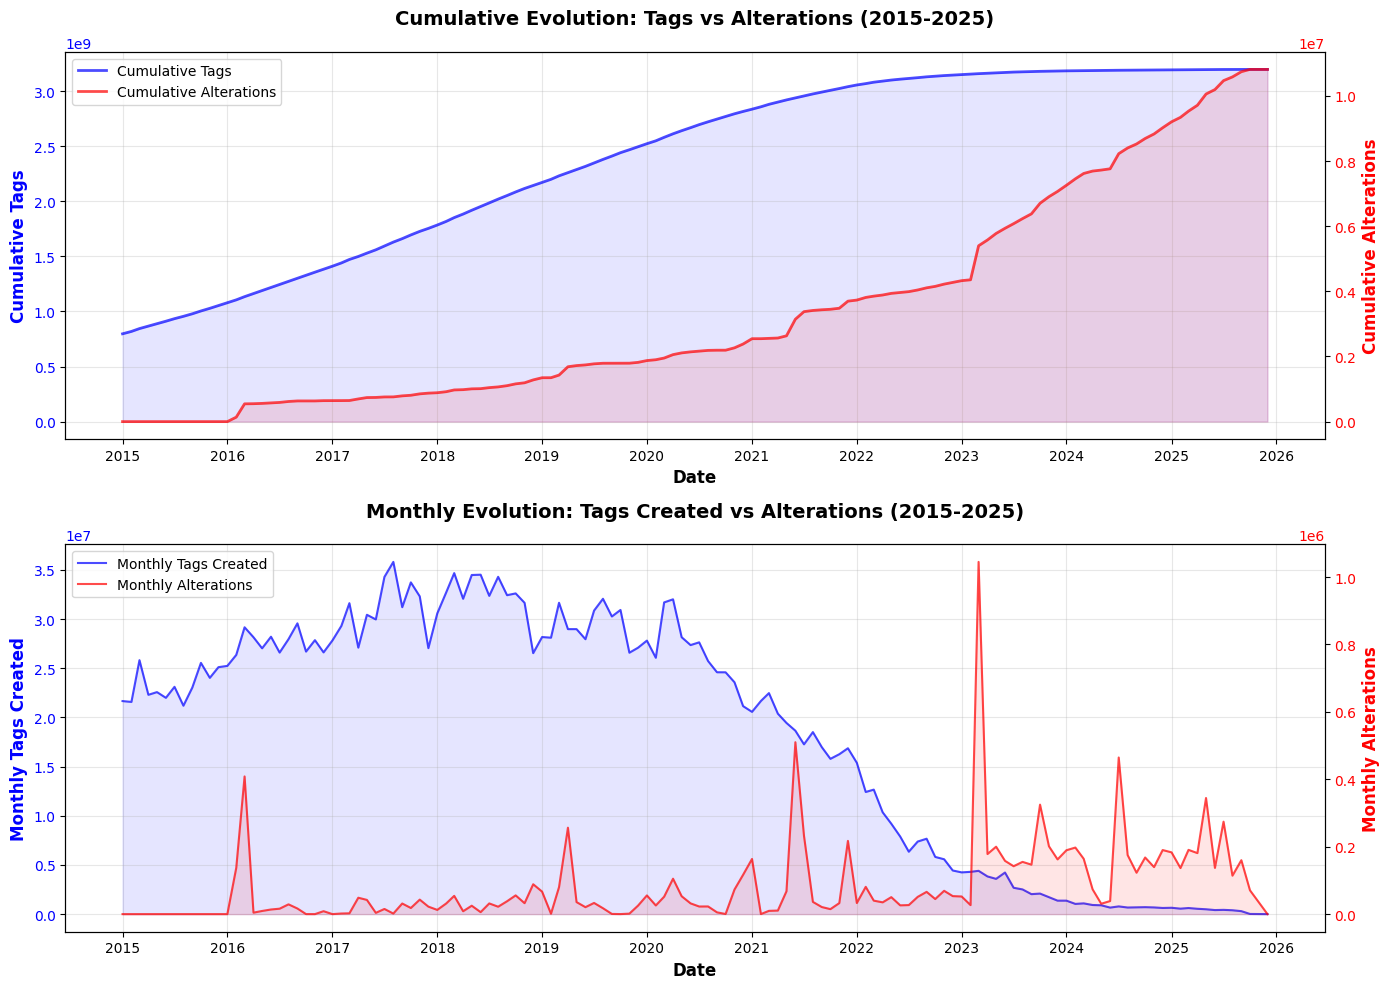


Cumulative alterations in period: 10_815_603
Cumulative tags at end of period: 3_196_218_750
Alteration rate in period: 0.3384%


In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# Convert month strings to datetime for better plotting
temporal_analysis['month_date'] = pd.to_datetime(temporal_analysis['month'] + '-01')

# Filter to only months with tag data AND between 2015-2026
plot_data = temporal_analysis[
    (temporal_analysis['total'] > 0) & 
    (temporal_analysis['month_date'] >= '2015-01-01') &
    (temporal_analysis['month_date'] < '2026-01-01')
].copy()

print(f"Plotting data from {plot_data['month_date'].min().strftime('%Y-%m')} to {plot_data['month_date'].max().strftime('%Y-%m')}")
print(f"Total months in range: {len(plot_data)}")
print()

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================
# FIGURE 1: Cumulative Evolution
# ============================================================
ax1_twin = ax1.twinx()

# Plot cumulative tags on left y-axis
line1 = ax1.plot(plot_data['month_date'], plot_data['cumulative_total'], 
                 'b-', linewidth=2, label='Cumulative Tags', alpha=0.7)
ax1.fill_between(plot_data['month_date'], 0, plot_data['cumulative_total'], 
                  alpha=0.1, color='blue')

# Plot cumulative alterations on right y-axis
cumulative_alterations = plot_data['total_alterations'].cumsum()
line2 = ax1_twin.plot(plot_data['month_date'], cumulative_alterations, 
                      'r-', linewidth=2, label='Cumulative Alterations', alpha=0.7)
ax1_twin.fill_between(plot_data['month_date'], 0, cumulative_alterations, 
                       alpha=0.1, color='red')

# Formatting
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Tags', fontsize=12, fontweight='bold', color='blue')
ax1_twin.set_ylabel('Cumulative Alterations', fontsize=12, fontweight='bold', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax1_twin.tick_params(axis='y', labelcolor='red')
ax1.set_title('Cumulative Evolution: Tags vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# ============================================================
# FIGURE 2: Monthly (Non-Cumulative) Evolution
# ============================================================
ax2_twin = ax2.twinx()

# Plot monthly tags created on left y-axis
line3 = ax2.plot(plot_data['month_date'], plot_data['total'], 
                 'b-', linewidth=1.5, label='Monthly Tags Created', alpha=0.7)
ax2.fill_between(plot_data['month_date'], 0, plot_data['total'], 
                  alpha=0.1, color='blue')

# Plot monthly alterations on right y-axis
line4 = ax2_twin.plot(plot_data['month_date'], plot_data['total_alterations'], 
                      'r-', linewidth=1.5, label='Monthly Alterations', alpha=0.7)
ax2_twin.fill_between(plot_data['month_date'], 0, plot_data['total_alterations'], 
                       alpha=0.1, color='red')

# Formatting
ax2.set_xlabel('Date', fontsize=12, fontweight='bold')
ax2.set_ylabel('Monthly Tags Created', fontsize=12, fontweight='bold', color='blue')
ax2_twin.set_ylabel('Monthly Alterations', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='blue')
ax2_twin.tick_params(axis='y', labelcolor='red')
ax2.set_title('Monthly Evolution: Tags Created vs Alterations (2015-2025)', fontsize=14, fontweight='bold', pad=20)
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(1))

# Add combined legend
lines = line3 + line4
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nCumulative alterations in period: {cumulative_alterations.iloc[-1]:_}")
print(f"Cumulative tags at end of period: {plot_data['cumulative_total'].iloc[-1]:_}")
print(f"Alteration rate in period: {(cumulative_alterations.iloc[-1] / plot_data['cumulative_total'].iloc[-1] * 100):.4f}%")

# Taxonomy

In [2]:
conn = sqlite3.connect('../data/tags_alterations_full_2025-10_v2.db')
diffs = pd.read_sql_query("SELECT * FROM tag_diffs", conn)
# files = pd.read_sql_query("SELECT * FROM tag_file_diffs", conn)

# print(f"Loaded {len(files):_} rows from database")
print(f"Loaded {len(diffs):_} rows from database")

Loaded 1_129_593 rows from database


In [3]:
diffs[diffs['rel_message_differs'].notna()].head(5)

,origin_url,tag_name,tag_type,old_snapshot,altering_snapshot,old_snap_timestamp,old_release_swhid,new_release_swhid,old_revision_swhid,new_revision_swhid,old_directory_swhid,new_directory_swhid,rel_message_differs,rel_author_differs,rel_author_timestamp_differs,rev_message_differs,rev_author_differs,rev_committer_differs,rev_author_timestamp_differs,rev_committer_timestamp_differs,dir_added,dir_deleted,dir_modified,dir_renamed
23,https://github.com/netsecsp/aftpx,refs/tags/1.2,annotated,swh:1:snp:904b1019f5dd78512b7243dbbda36ec5a84d0b2a,swh:1:snp:3a52110e1afc36346e5527be9ead961263dde088,1652829509,swh:1:rel:a737d81fe8a3478a062cd66e7f91a48aee0700f6,swh:1:rel:43efe98c75aa10c233f80dc782071a2d0321defe,swh:1:rev:3d97b7f47634df91fcaa6c617613f2f0f171d384,swh:1:rev:7b76beb54d8d80161cd06a346700b6906313a632,swh:1:dir:d9cd4b4fcf23f4429c071597f43276204dc7cdb7,swh:1:dir:72201067c1d5cbcf97f868d6003be04f2921fba3,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,2.0,2.0,81.0,0.0
24,https://github.com/exploratory-io/exploratory_func,refs/tags/v9.0.4,annotated,swh:1:snp:6e29672775e540b94eb7eceb90ae429407d52149,swh:1:snp:eedde52d07f0ec818a36fb712329dd4473cdcdd6,1709319338,swh:1:rel:3dc0e2da0b2ff65b3b8cfebff9d8d590bdc28366,swh:1:rel:aa9d6b69577021b1aeb3802e2ebd0bff6beb2380,swh:1:rev:6f16e42648dd6b2aa20adf7bd21ba05809beb521,swh:1:rev:67f5e3eb3c11c3ec94f9ca7b107beec715959777,swh:1:dir:20090e6f09b35a1c653e8cc65af9ccc2c42d2895,swh:1:dir:8db796a63b61f2cc1a52a53b3bfb4e7356467947,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
55,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.8.2,annotated,swh:1:snp:4631c43cdc09ed21389ea06cd43ad988ab5041b6,swh:1:snp:faa054d9b46d6609ec763f84af3b37141f5c16a5,1666003050,swh:1:rel:187c2101fc1e5b1c4b04489a383c820b9588933e,swh:1:rel:cb29d1ae31ddce2e021a5d4b06b202a9d620c16a,swh:1:rev:511eb592045ff064c0b0fac4b4c09fa42c4e0551,swh:1:rev:7b16607ec0bbd65e65d3f4b625b529fb77cfc281,swh:1:dir:effb81e567c548e781a2af75e83e6d7955e67c2c,swh:1:dir:e9a763df018b77a35c813e0d43ff62f45e5ba862,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,23.0,0.0,207.0,0.0
56,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.7.4,annotated,swh:1:snp:26bfb178d3f536a32fdc73a580f2d19536546609,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1643061100,swh:1:rel:aef92a8b2b184e6347065b045527de71519ae4a6,swh:1:rel:cbf0ab0a978e3cee8060d01129a42e079e618117,swh:1:rev:d543b7d0c39818bf540fbbc866642c0a7d5eefb4,swh:1:rev:0ebadd8441f7c13677db75ee03fcc3320b143b00,swh:1:dir:2b217826ccc3dfa6fea64e4918c24959da8ea6d5,swh:1:dir:e864a8962ff5290a191534da3506be46fb72fb16,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,2.0,3.0,0.0
57,https://github.com/ThinkingDataAnalytics/ios-sdk,refs/tags/v2.6.5,annotated,swh:1:snp:222e793009529ccda47ee5a06f6fda7e21019b73,swh:1:snp:c1bfc417776f6953aff26ef2600d63958cce1940,1624392023,swh:1:rel:fd2f90d38ecb1de4c84af0f582d2457086715d6e,swh:1:rel:7719a776db33e95b3f7f0349ad704805a208dc06,swh:1:rev:8c7b7408af11fef73875e72146ce969f9fb7a75c,swh:1:rev:eb447ab7a232039600583afd074339ec345e50e6,swh:1:dir:e208f8a221391409745e506a210545b8b1532d68,swh:1:dir:7ddd936b243a754a807f7a89a689d9680a5aa6ee,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [4]:
# Compute statistics for diffs dataframe

# 1. Identify rows with rel changes (sum of differs >= 1)
rel_cols = ['rel_message_differs', 'rel_author_differs', 'rel_author_timestamp_differs']
diffs['has_rel_changes'] = diffs[rel_cols].notna().sum(axis=1) >= 1

# 2. Identify rows with rev changes (sum of differs >= 1)
rev_cols = ['rev_message_differs', 'rev_author_differs', 'rev_committer_differs', 
            'rev_author_timestamp_differs', 'rev_committer_timestamp_differs']
diffs['has_rev_changes'] = diffs[rev_cols].notna().sum(axis=1) >= 1

# 3. Identify rows with dir changes (only when old_directory != new_directory)
diffs['has_dir_changes'] = (diffs['old_directory_swhid'] != diffs['new_directory_swhid']) & \
                            (diffs['old_directory_swhid'].notna()) & \
                            (diffs['new_directory_swhid'].notna())

# Count rows with each type of change
total_rows = len(diffs)
rel_count = diffs['has_rel_changes'].sum()
rev_count = diffs['has_rev_changes'].sum()
dir_count = diffs['has_dir_changes'].sum()

print("=" * 60)
print("CHANGES IN DIFFS DATAFRAME")
print("=" * 60)
print(f"Total rows: {total_rows:_}")
print()
print(f"Release changes:   {rel_count:_} rows ({rel_count/total_rows*100:.2f}%)")
print(f"Revision changes:  {rev_count:_} rows ({rev_count/total_rows*100:.2f}%)")
print(f"Directory changes: {dir_count:_} rows ({dir_count/total_rows*100:.2f}%)")
print()

# Directory statistics (only for rows where directories differ)
dir_changed_rows = diffs[diffs['has_dir_changes']]
print("=" * 60)
print("DIRECTORY CHANGE STATISTICS")
print("(Only for rows where old_directory != new_directory)")
print("=" * 60)

if len(dir_changed_rows) > 0:
    dir_stats_cols = ['dir_added', 'dir_deleted', 'dir_modified', 'dir_renamed']
    for col in dir_stats_cols:
        mean_val = dir_changed_rows[col].mean()
        median_val = dir_changed_rows[col].median()
        total_val = dir_changed_rows[col].sum()
        print(f"\n{col}:")
        print(f"  Mean:   {mean_val:.2f}")
        print(f"  Median: {median_val:.0f}")
        print(f"  Total:  {total_val:_}")
else:
    print("No directory changes found")
    
print("\n" + "=" * 60)

CHANGES IN DIFFS DATAFRAME
Total rows: 1_129_593

Release changes:   184_888 rows (16.37%)
Revision changes:  654_004 rows (57.90%)
Directory changes: 441_082 rows (39.05%)

DIRECTORY CHANGE STATISTICS
(Only for rows where old_directory != new_directory)

dir_added:
  Mean:   443.84
  Median: 1
  Total:  195_770_425.0

dir_deleted:
  Mean:   136.00
  Median: 1
  Total:  59_989_137.0

dir_modified:
  Mean:   499.45
  Median: 5
  Total:  220_297_582.0

dir_renamed:
  Mean:   41.45
  Median: 0
  Total:  18_283_017.0



In [6]:
# Detailed statistics for each type of change

print("=" * 70)
print("DETAILED RELEASE CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with release changes: {rel_count:_}\n")

rel_cols = ['rel_message_differs', 'rel_author_differs', 'rel_author_timestamp_differs']
for col in rel_cols:
    count = ((diffs[col].notna()) & (diffs[col] > 0)).sum()
    pct_of_rel = (count / rel_count * 100) if rel_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col}:")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_rel:.2f}% of rows with rel changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()

print("=" * 70)
print("DETAILED REVISION CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with revision changes: {rev_count:_}\n")

rev_cols = ['rev_message_differs', 'rev_author_differs', 'rev_committer_differs', 
            'rev_author_timestamp_differs', 'rev_committer_timestamp_differs']
for col in rev_cols:
    count = ((diffs[col].notna()) & (diffs[col] > 0)).sum()
    pct_of_rev = (count / rev_count * 100) if rev_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col}:")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_rev:.2f}% of rows with rev changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()

print("=" * 70)
print("DETAILED DIRECTORY CHANGE STATISTICS")
print("=" * 70)
print(f"Total rows with directory changes: {dir_count:_}\n")

dir_cols = ['dir_added', 'dir_deleted', 'dir_modified', 'dir_renamed']
for col in dir_cols:
    # Count rows where this column > 0
    count = (dir_changed_rows[col] > 0).sum()
    pct_of_dir = (count / dir_count * 100) if dir_count > 0 else 0
    pct_of_total = count / total_rows * 100
    print(f"{col} (rows with at least 1 file):")
    print(f"  Count: {count:_}")
    print(f"  {pct_of_dir:.2f}% of rows with dir changes")
    print(f"  {pct_of_total:.2f}% of total diffs rows")
    print()
    
print("=" * 70)

DETAILED RELEASE CHANGE STATISTICS
Total rows with release changes: 184_888

rel_message_differs:
  Count: 39_618
  21.43% of rows with rel changes
  3.51% of total diffs rows

rel_author_differs:
  Count: 28_069
  15.18% of rows with rel changes
  2.48% of total diffs rows

rel_author_timestamp_differs:
  Count: 79_590
  43.05% of rows with rel changes
  7.05% of total diffs rows

DETAILED REVISION CHANGE STATISTICS
Total rows with revision changes: 654_004

rev_message_differs:
  Count: 309_313
  47.30% of rows with rev changes
  27.38% of total diffs rows

rev_author_differs:
  Count: 186_595
  28.53% of rows with rev changes
  16.52% of total diffs rows

rev_committer_differs:
  Count: 181_533
  27.76% of rows with rev changes
  16.07% of total diffs rows

rev_author_timestamp_differs:
  Count: 333_128
  50.94% of rows with rev changes
  29.49% of total diffs rows

rev_committer_timestamp_differs:
  Count: 354_048
  54.14% of rows with rev changes
  31.34% of total diffs rows

DETA

# Popularity

In [37]:
# Define star ranges
def categorize_stars(stars):
    if pd.isna(stars):
        return 'Unknown'
    elif stars <= 1:
        return '0-1 star'
    elif stars <= 10:
        return '2-10 stars'
    elif stars <= 100:
        return '11-100 stars'
    elif stars <= 500:
        return '101-500 stars'
    else:
        return '500+ stars'

df['star_range'] = df['stars'].apply(categorize_stars)

# Group by star range
star_stats = df.groupby('star_range').agg({
    'tag_name': 'count',    
    'origin_url': 'nunique',
    'stars': ['min', 'max', 'mean', 'median']
}).reset_index()

# Flatten column names
star_stats.columns = ['star_range', 'total_alterations', 'unique_origins', 'min_stars', 'max_stars', 'mean_stars', 'median_stars']

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
star_stats['order'] = star_stats['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
star_stats = star_stats.sort_values('order').drop(columns=['order'])

# Calculate proportions
star_stats['pct_alterations'] = (star_stats['total_alterations'] / star_stats['total_alterations'].sum() * 100)
star_stats['pct_origins'] = (star_stats['unique_origins'] / star_stats['unique_origins'].sum() * 100)

print("=" * 80)
print("ALTERATIONS BY REPOSITORY STAR COUNT")
print("=" * 80)
print(f"Total alterations analyzed: {len(df):_}")
print(f"Total unique origins: {df['origin_url'].nunique():_}")
print()

for idx, row in star_stats.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Alterations: {row['total_alterations']:_} ({row['pct_alterations']:.2f}%)")
    print(f"  Unique origins: {row['unique_origins']:_} ({row['pct_origins']:.2f}%)")
    if row['star_range'] != 'Unknown':
        print(f"  Star range: {row['min_stars']:.0f} - {row['max_stars']:.0f}")
        print(f"  Mean stars: {row['mean_stars']:.1f}")
        print(f"  Median stars: {row['median_stars']:.0f}")
    print(f"  Avg alterations per origin: {row['total_alterations'] / row['unique_origins']:.2f}")

print("\n" + "=" * 80)

ALTERATIONS BY REPOSITORY STAR COUNT
Total alterations analyzed: 10_815_603
Total unique origins: 227_635


0-1 star:
  Alterations: 7_849_587 (72.58%)
  Unique origins: 120_152 (52.78%)
  Star range: 0 - 1
  Mean stars: 0.1
  Median stars: 0
  Avg alterations per origin: 65.33

2-10 stars:
  Alterations: 384_288 (3.55%)
  Unique origins: 25_537 (11.22%)
  Star range: 2 - 10
  Mean stars: 4.8
  Median stars: 4
  Avg alterations per origin: 15.05

11-100 stars:
  Alterations: 392_570 (3.63%)
  Unique origins: 19_629 (8.62%)
  Star range: 11 - 100
  Mean stars: 32.6
  Median stars: 23
  Avg alterations per origin: 20.00

101-500 stars:
  Alterations: 253_776 (2.35%)
  Unique origins: 7_864 (3.45%)
  Star range: 101 - 500
  Mean stars: 232.1
  Median stars: 195
  Avg alterations per origin: 32.27

500+ stars:
  Alterations: 636_681 (5.89%)
  Unique origins: 6_780 (2.98%)
  Star range: 501 - 216640
  Mean stars: 8968.1
  Median stars: 904
  Avg alterations per origin: 93.91

Unknown:
  Alt

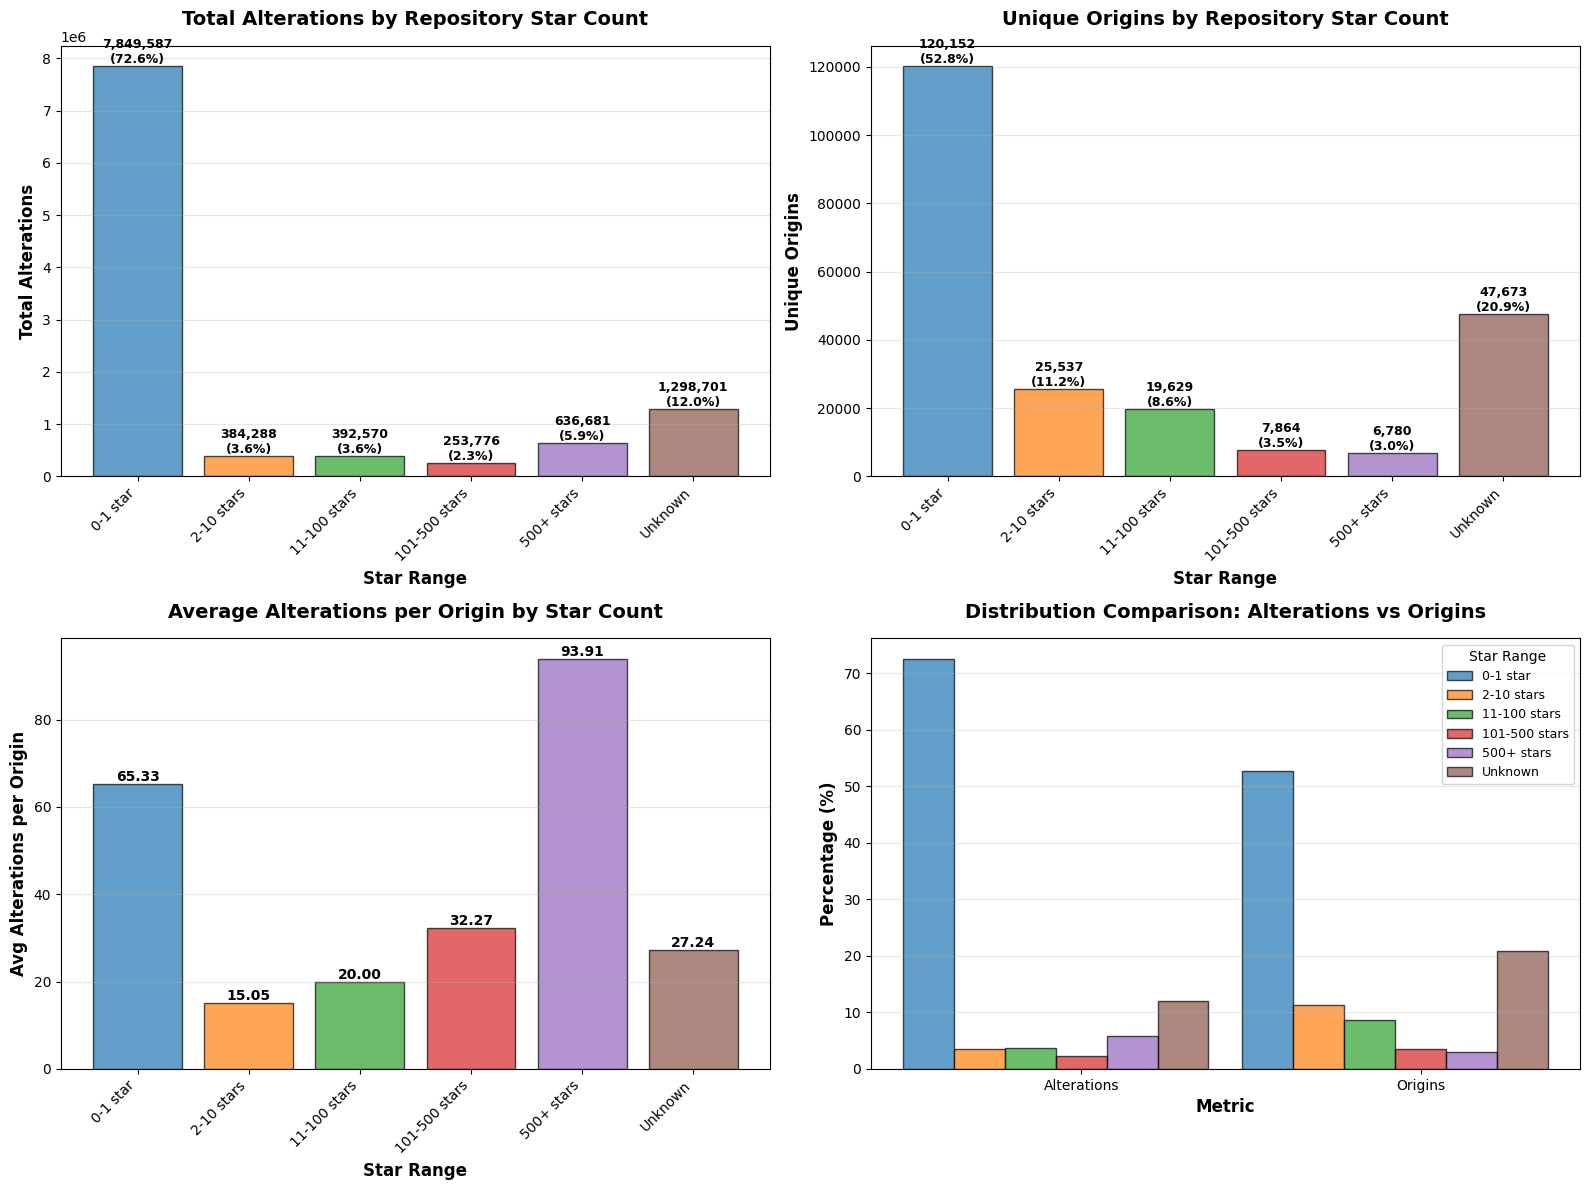


Visualization complete!
Key insights:
  - Most alterations come from: 0-1 star
  - Most origins in range: 0-1 star
  - Highest avg alterations per origin: 500+ stars (93.91)


In [ ]:
# Visualize star count statistics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define star order for plotting (exclude Unknown for some plots)
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
x_pos = range(len(star_stats))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

# ============================================================
# PLOT 1: Total Alterations by Star Range (Bar Chart)
# ============================================================
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos, star_stats['total_alterations'], color=colors, alpha=0.7, edgecolor='black')
ax1.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Alterations', fontsize=12, fontweight='bold')
ax1.set_title('Total Alterations by Repository Star Count', fontsize=14, fontweight='bold', pad=15)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['total_alterations']
    ax1.text(i, height, f"{height:,}\n({row['pct_alterations']:.1f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================
# PLOT 2: Unique Origins by Star Range (Bar Chart)
# ============================================================
ax2 = axes[0, 1]
bars2 = ax2.bar(x_pos, star_stats['unique_origins'], color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax2.set_ylabel('Unique Origins', fontsize=12, fontweight='bold')
ax2.set_title('Unique Origins by Repository Star Count', fontsize=14, fontweight='bold', pad=15)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['unique_origins']
    ax2.text(i, height, f"{height:,}\n({row['pct_origins']:.1f}%)", 
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================
# PLOT 3: Average Alterations per Origin (Bar Chart)
# ============================================================
ax3 = axes[1, 0]
star_stats['avg_per_origin'] = star_stats['total_alterations'] / star_stats['unique_origins']
bars3 = ax3.bar(x_pos, star_stats['avg_per_origin'], color=colors, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax3.set_ylabel('Avg Alterations per Origin', fontsize=12, fontweight='bold')
ax3.set_title('Average Alterations per Origin by Star Count', fontsize=14, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(star_stats['star_range'], rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(star_stats.iterrows()):
    height = row['avg_per_origin']
    ax3.text(i, height, f"{height:.2f}", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# ============================================================
# PLOT 4: Proportion of Origins with Alterations
# ============================================================
ax4 = axes[1, 1]
bars4 = ax4.bar(x_pos, proportion_analysis['proportion_with_alterations'], color=colors, alpha=0.7, edgecolor='black')
ax4.set_xlabel('Star Range', fontsize=12, fontweight='bold')
ax4.set_ylabel('Proportion (%)', fontsize=12, fontweight='bold')
ax4.set_title('Proportion of Origins with ≥1 Alteration by Star Count', fontsize=14, fontweight='bold', pad=15)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(proportion_analysis['star_range'], rotation=45, ha='right')
ax4.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (idx, row) in enumerate(proportion_analysis.iterrows()):
    height = row['proportion_with_alterations']
    ax4.text(i, height, f"{height:.4f}%\n({row['origins_with_alterations']:,}/{row['total_origins']:,})", 
             ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Key insights:")
print(f"  - Most alterations come from: {star_stats.loc[star_stats['total_alterations'].idxmax(), 'star_range']}")
print(f"  - Most origins in range: {star_stats.loc[star_stats['unique_origins'].idxmax(), 'star_range']}")
print(f"  - Highest avg alterations per origin: {star_stats.loc[star_stats['avg_per_origin'].idxmax(), 'star_range']} ({star_stats['avg_per_origin'].max():.2f})")
print(f"  - Highest proportion with alterations: {proportion_analysis.loc[proportion_analysis['proportion_with_alterations'].idxmax(), 'star_range']} ({proportion_analysis['proportion_with_alterations'].max():.4f}%)")

In [ ]:
stars = pd.read_pickle("/home/infres/rapaport/datasets/github-stars/github-stars.pkl")

In [40]:
# Compute proportion of origins with at least 1 alteration per star range

# Categorize all origins in the stars dataset by star range
stars['star_range'] = stars['stars'].apply(categorize_stars)

# Count total origins per star range (from the full stars dataset)
total_origins_per_range = stars.groupby('star_range').size().reset_index(name='total_origins')

# Origins with at least 1 alteration per star range (from star_stats)
origins_with_alterations = star_stats[['star_range', 'unique_origins']].copy()
origins_with_alterations.columns = ['star_range', 'origins_with_alterations']

# Merge the two
proportion_analysis = total_origins_per_range.merge(origins_with_alterations, on='star_range', how='left')
proportion_analysis['origins_with_alterations'] = proportion_analysis['origins_with_alterations'].fillna(0).astype(int)

# Calculate proportion
proportion_analysis['proportion_with_alterations'] = (
    proportion_analysis['origins_with_alterations'] / proportion_analysis['total_origins'] * 100
)

# Order by star range
star_order = ['0-1 star', '2-10 stars', '11-100 stars', '101-500 stars', '500+ stars', 'Unknown']
proportion_analysis['order'] = proportion_analysis['star_range'].apply(lambda x: star_order.index(x) if x in star_order else 999)
proportion_analysis = proportion_analysis.sort_values('order').drop(columns=['order'])

print("=" * 90)
print("PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE")
print("=" * 90)
print(f"Total unique origins in stars dataset: {len(stars):_}")
print(f"Total unique origins with alterations: {df['origin_url'].nunique():_}")
print()

for idx, row in proportion_analysis.iterrows():
    print(f"\n{row['star_range']}:")
    print(f"  Total origins in range: {row['total_origins']:_}")
    print(f"  Origins with ≥1 alteration: {row['origins_with_alterations']:_}")
    print(f"  Proportion: {row['proportion_with_alterations']:.4f}%")

print("\n" + "=" * 90)

# Display as dataframe
proportion_analysis[['star_range', 'total_origins', 'origins_with_alterations', 'proportion_with_alterations']]

PROPORTION OF ORIGINS WITH AT LEAST 1 ALTERATION BY STAR RANGE
Total unique origins in stars dataset: 437_674_730
Total unique origins with alterations: 227_635


0-1 star:
  Total origins in range: 417_722_070
  Origins with ≥1 alteration: 120_152
  Proportion: 0.0288%

2-10 stars:
  Total origins in range: 13_478_707
  Origins with ≥1 alteration: 25_537
  Proportion: 0.1895%

11-100 stars:
  Total origins in range: 4_364_186
  Origins with ≥1 alteration: 19_629
  Proportion: 0.4498%

101-500 stars:
  Total origins in range: 1_261_995
  Origins with ≥1 alteration: 7_864
  Proportion: 0.6231%

500+ stars:
  Total origins in range: 847_772
  Origins with ≥1 alteration: 6_780
  Proportion: 0.7997%



,star_range,total_origins,origins_with_alterations,proportion_with_alterations
0,0-1 star,417722070,120152,0.028764
3,2-10 stars,13478707,25537,0.189462
2,11-100 stars,4364186,19629,0.449775
1,101-500 stars,1261995,7864,0.623140
4,500+ stars,847772,6780,0.799743
